# Random Forest(랜덤포레스트) 
## 랜덤 포레스트 (Random Forest) 모델 개요
* **정의**: 배깅(Bagging) 기법을 기반으로 하며, 여러 개의 의사결정나무(Decision Tree)를 결합하여 하나의 강력한 예측 성능을 내는 대표적인 앙상블 모델.
* **핵심 원리**: 각 의사결정나무가 서로 다른 데이터 샘플과 **변수(Feature)의 서브셋**을 무작위로 선택하여 독립적으로 학습함. 최종 예측은 분류의 경우 다수결 투표, 회귀의 경우 평균값으로 결합함.

### 작동 원리 및 주요 특징
1. **배깅(Bootstrap Aggregating) 적용**: 원본 데이터에서 중복을 허용하여 무작위 복원 추출(Bootstrap Sampling)을 수행함. 개별 나무들이 서로 다른 데이터를 학습하게 하여 특정 데이터 의존성을 줄이고 과적합(Overfitting)을 방지함.
2. **변수 샘플링(Feature Sampling)**: 데이터를 샘플링할 뿐만 아니라, 나무의 노드를 분할할 때 전체 특성 중 일부 특성만 랜덤하게 선택하여 학습함. 모델 간의 상관성을 줄여 예측 결과의 안정성을 극대화함.
3. **장점**: 노이즈와 이상치에 강하며, 병렬 처리가 가능하여 대규모 데이터에서도 비교적 효율적으로 학습함. 특성 중요도(Feature Importance) 계산을 통해 모델 해석이 가능함.
4. **단점**: 많은 수의 나무를 생성하므로 예측 및 학습 시 계산 비용(시간, 메모리)이 증가하며, 모델 내부의 복잡한 구조로 인해 단일 트리에 비해 직관적인 해석은 어려움.

Random Forest Accuracy: 0.8688524590163934

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.83      0.86        29
           1       0.85      0.91      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61


Feature Importances (Descending Order):
caa: 0.1367
oldpeak: 0.1326
cp: 0.1245
thall: 0.1174
thalachh: 0.1012
exng: 0.0940
age: 0.0771
slp: 0.0571
trtbps: 0.0517
chol: 0.0506
sex: 0.0327
restecg: 0.0163
fbs: 0.0083


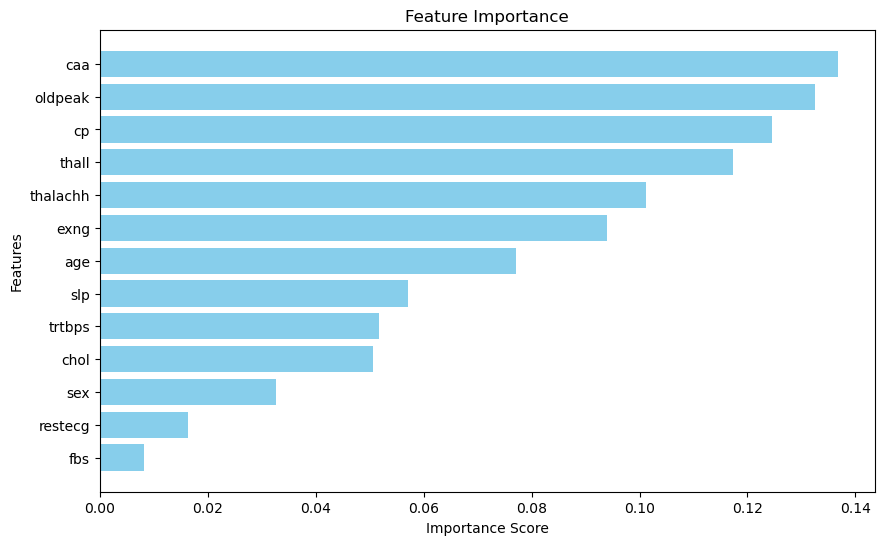

In [1]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. 데이터 로드 및 분리
data = pd.read_csv('C:/juehyeon/aice_test/materials/datasets/heart.csv')
X = data.drop('output', axis=1) # 독립 변수 (특성)
y = data['output']              # 종속 변수 (심장병 여부)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 랜덤 포레스트 모델 생성 및 학습
rf_model = RandomForestClassifier(
    n_estimators=100,  # 생성할 의사결정나무의 개수
    max_depth=5,       # 트리의 최대 깊이 제한 (과적합 방지)
    random_state=42    # 결과 재현성 유지
)
rf_model.fit(X_train, y_train)

# 3. 테스트 데이터 예측 및 평가
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)
print("\nClassification Report:\n", report)

# 4. 특성 중요도(Feature Importance) 계산 및 정렬
feature_importances = rf_model.feature_importances_
features = X.columns

sorted_idx = np.argsort(feature_importances)[::-1] # 중요도 기준 내림차순 정렬
sorted_features = features[sorted_idx]
sorted_importances = feature_importances[sorted_idx]

# 표 형태로 출력
print("\nFeature Importances (Descending Order):")
for feature, importance in zip(sorted_features, sorted_importances):
    print(f"{feature}: {importance:.4f}")

# 5. 특성 중요도 시각화
plt.figure(figsize=(10, 6))
plt.barh(sorted_features, sorted_importances, color='skyblue')
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis() # 중요도가 높은 특성이 위로 오도록 설정
plt.show()